## Model Training

In [40]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

file_path = os.path.abspath("../data/processed_features.csv")
df_m = pd.read_csv(file_path)

# === Prepare Features and Target ===
# Drop target and unrelated columns from features
X = df_m.drop(columns=["SteamSpyOwners", "HighQualityDeveloper", "HighQualityPublisher"])
y = df_m["SteamSpyOwners"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Train Gradient Boosting Regressor ===
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)



# Replace with your Gradient Boosting Regressor instance
#model = GradientBoostingRegressor()
# After training your model, save it:

file_path = os.path.abspath('../project/app/trained_model.pkl')
with open(file_path, "wb") as file:
    pickle.dump(model, file)

# === Make Predictions ===
y_pred = model.predict(X_test)

# === Evaluate Model ===
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f}")


R² Score: 0.971
Mean Absolute Error: 27885.08


In [41]:
file_path = os.path.abspath("../data/processed_features.csv")
df_m = pd.read_csv(file_path)
df_m.columns

Index(['RecommendationCount', 'SteamSpyOwners', 'Achievements', 'Adventure',
       'Casual', 'Indie', 'RPG', 'Free To Play', 'Action', 'Strategy',
       'Simulation', 'Racing', 'Sports', 'Massively Multiplayer', 'Education',
       'Violent', 'Design & Illustration', 'Animation & Modeling', 'Co-op',
       'Cross-Platform Multiplayer', 'Family Sharing', 'HDR available',
       'In-App Purchases', 'Multi-player', 'VR Support', 'age_ranking',
       'Price', 'dlc_count', 'rating', 'TotalReviews', 'ReviewScore', 'Sales',
       'avg_playtime', 'YearDifference', 'Month_sin', 'Month_cos',
       'balance_pos_neg', 'PurchaseAvail', 'CategorySinglePlayer',
       'TotalPoints', 'Budget_AA', 'Budget_AAA', 'Budget_Indie', 'cpu_ghz',
       'ram_gb', 'storage_gb', 'PriceCategory_High', 'PriceCategory_Low',
       'PriceCategory_Medium', 'HighQualityDeveloper', 'HighQualityPublisher'],
      dtype='object')

In [ ]:


X = df_m[['PriceCategory_High', 'PriceCategory_Low','PriceCategory_Medium',

       'avg_playtime',

       'Budget_AA', 'Budget_AAA', 'Budget_Indie',

       'ram_gb','storage_gb','cpu_ghz',

       'dlc_count','age_ranking','Achievements',

       'Adventure', 'Casual',
       'RPG', 'Action', 'Strategy', 'Simulation', 'Racing',
       'Sports', 'Massively Multiplayer', 'Education', 'Violent',
       'Design & Illustration', 'Animation & Modeling', 'Co-op',
       'Cross-Platform Multiplayer',  'Multi-player']]


y = df_m["SteamSpyOwners"]
X.columns
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
X_train.columns

Index(['Price', 'PriceCategory_High', 'PriceCategory_Low',
       'PriceCategory_Medium', 'avg_playtime', 'Budget_AA', 'Budget_AAA',
       'Budget_Indie', 'ram_gb', 'storage_gb', 'cpu_ghz', 'dlc_count',
       'age_ranking', 'Achievements', 'Adventure', 'Casual', 'RPG', 'Action',
       'Strategy', 'Simulation', 'Racing', 'Sports', 'Massively Multiplayer',
       'Education', 'Violent', 'Design & Illustration', 'Animation & Modeling',
       'Co-op', 'Cross-Platform Multiplayer', 'Multi-player'],
      dtype='object')

R² Score: 0.477
Mean Absolute Error: 168870.58


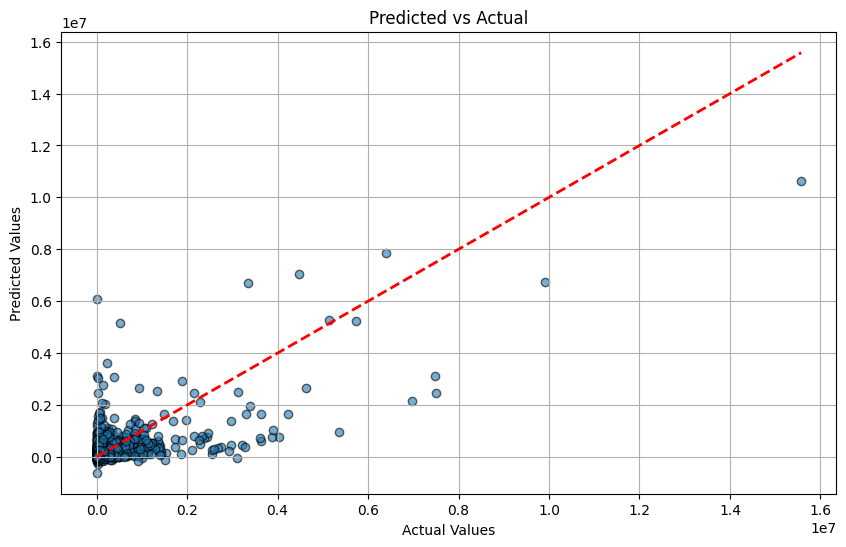

Predictions saved to 'gradient_boosting_predictions.csv'


In [66]:
# === Fit the Gradient Boosting Model ===
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Train the model on the entire dataset
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# file_path = os.path.abspath('../project/app/trained_model.pkl')
# with open(file_path, "wb") as file:
#     pickle.dump(model, file)


# === Make Predictions ===
y_pred = model.predict(X_test)

# === Evaluate Model ===
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f}")

# === Visualize Predicted vs Actual ===
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--r", linewidth=2)
plt.title("Predicted vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

# === Save Predictions for Analysis ===
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Save to CSV for further inspection
predictions_df.to_csv("gradient_boosting_predictions.csv", index=False)

print("Predictions saved to 'gradient_boosting_predictions.csv'")


In [45]:
# === Revenue Prediction ===
df_test = X_test.copy()
df_test["PredictedOwners"] = y_pred

# Calculate estimated revenue
df_test["EstimatedRevenue"] = df_test["PredictedOwners"] * df_test["Price"]

# Display summary statistics of revenue
print(df_test["EstimatedRevenue"].describe())

# Save revenue predictions for further analysis
df_test.to_csv("predicted_revenue.csv", index=False)

print("Revenue predictions saved to 'predicted_revenue.csv'")


KeyError: 'Price'